# Reproducing figures from Chapter 7 of Edition 2



In [3]:
colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'


## SEIR

C:\Users\JCMiller\Dropbox\work\SpringerGithub\EoN\analytic.py:3404: RuntimeWarning: divide by zero encountered in divide
  Kfactor = np.where(Kvec==0, 0, (Kvec - 1) / Kvec ) # (k-1)/k for each k in K, except k=0 where it is 0.
C:\Users\JCMiller\Dropbox\work\SpringerGithub\EoN\analytic.py:3408: RuntimeWarning: invalid value encountered in divide
  term_ix = np.where(Qik[:,None] == 0, 0, bijz * Kfactor[:,None] * (QzQik[:,None] * QikQxl) / Qik[:,None]) #0 where den=0, otherwise using ratio
C:\Users\JCMiller\Dropbox\work\SpringerGithub\EoN\analytic.py:3412: RuntimeWarning: invalid value encountered in divide
  term_xi = np.where(Qik == 0, 0, bijz * Kfactor*(QxlQik*QikQz)/ Qik) #0 where den=0, otherwise using ratio


return_full_data should return edge counts as well


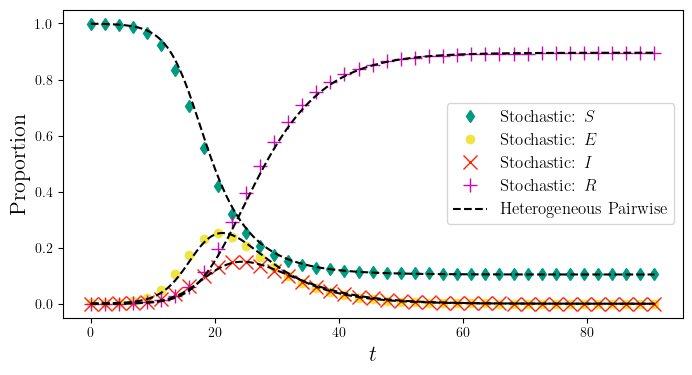

In [1]:
from matplotlib import rc 
import matplotlib.pyplot as plt
import networkx as nx
import EoN
import numpy as np
from collections import defaultdict

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'


#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)



rng = np.random.default_rng(seed = 1)

sigma = 0.2
gamma = 0.3
tau = 0.5

N=100000
initial_E_count = 100


deg_dist = [2]*int(N/2) + [5]*int(3*N/8) +  [15]*int(N/8)
rng.shuffle(deg_dist)
G = nx.configuration_model(deg_dist)
G.remove_edges_from(nx.selfloop_edges(G))

H_seir = nx.DiGraph()
H_seir.add_weighted_edges_from([('E', 'I', sigma), ('I', 'R', gamma)], weight='rate')

J_seir = nx.DiGraph()
J_seir.add_edge(('I', 'S'), ('I', 'E'), rate = tau)

fig = plt.figure(figsize=(8,4))

IC = defaultdict(lambda: 'S')
for node in range(initial_E_count):
    IC[node] = 'E'

return_statuses = ['S', 'E', 'I', 'R']

t_stoch, S_stoch, E_stoch, I_stoch, R_stoch = EoN.Gillespie_simple_contagion(G, H_seir, J_seir, IC, return_statuses=return_statuses, )  
S_stoch, I_stoch, R_stoch = EoN.subsample(np.linspace(0,t_stoch[-1],41), t_stoch, S_stoch, I_stoch, R_stoch)
E_stoch = EoN.subsample(np.linspace(0,t_stoch[-1],41), t_stoch, E_stoch)
t_stoch=np.linspace(0,t_stoch[-1],41)

plt.plot(t_stoch, S_stoch/N, 'd', label = 'Stochastic: $S$', color=colorS)
plt.plot(t_stoch, E_stoch/N, 'o', label = 'Stochastic: $E$', color=colorE)
plt.plot(t_stoch, I_stoch/N, 'x', label = 'Stochastic: $I$', markersize = 10, color=colorI)
plt.plot(t_stoch, R_stoch/N, '+', label = 'Stochastic: $R$', markersize = 10, color=colorR)

tt, SS, EE, II, RR = EoN.Simple_contagion_heterogeneous_pairwise_from_graph(G, H_seir, J_seir, IC, return_statuses,return_statuses=return_statuses, tmax=t_stoch[-1])

plt.plot(tt, SS/N, '--', label='Heterogeneous Pairwise', color='k')
plt.plot(tt, EE/N, '--', color='k')
plt.plot(tt, II/N, '--', color='k')
plt.plot(tt, RR/N, '--', color='k')

plt.legend(fontsize=12)
plt.xlabel('$t$', fontsize = 16)
plt.ylabel('Proportion', fontsize=16)

plt.savefig('SEIR_vs_HPW.png', dpi=900)


## SIRS

initial conditions set
omega = 0.8
stoch done
return_full_data should return edge counts as well
het pairwise done
omega = 0.4
stoch done
return_full_data should return edge counts as well
het pairwise done
omega = 0.2
stoch done
return_full_data should return edge counts as well
het pairwise done
omega = 0.1
stoch done
return_full_data should return edge counts as well
het pairwise done
omega = 0.05
stoch done
return_full_data should return edge counts as well
het pairwise done


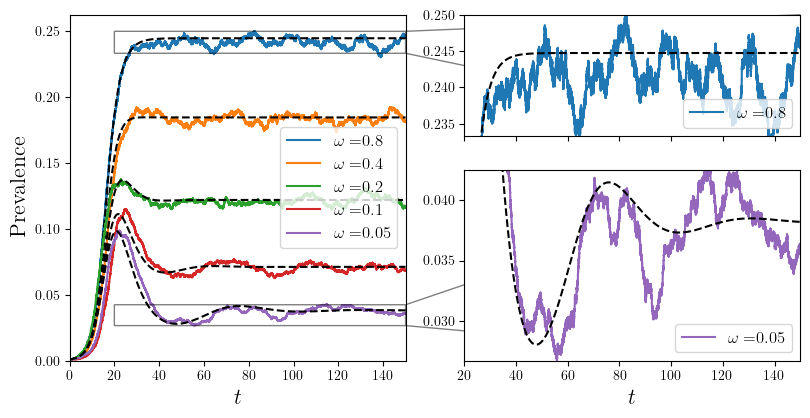

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
import EoN
import numpy as np
from collections import defaultdict
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'

rng = np.random.default_rng(seed = 1)

gamma = 0.3
tau = 0.1

N=30000
initial_I_count = 30
tmax=150


deg_dist = [2]*int(N/2) + [5]*int(3*N/8) +  [15]*int(N/8)
rng.shuffle(deg_dist)
G = nx.configuration_model(deg_dist)
G.remove_edges_from(nx.selfloop_edges(G))

# H_sirs = nx.DiGraph()
# H_sirs.add_weighted_edges_from([ ('I', 'R', gamma), ('R', 'S', omega)], weight='rate')

J_sirs = nx.DiGraph()
J_sirs.add_edge(('I', 'S'), ('I', 'I'), rate = tau)

#fig, ax = plt.subplots(figsize=(8,4))
fig = plt.figure(figsize=(8,4))
IC = defaultdict(lambda: 'S')
for node in range(initial_I_count):
    IC[node] = 'I'

return_statuses = ['S', 'I', 'R']

print('initial conditions set')


mainax = fig.add_axes([0.08,0.12,0.42, 0.865])

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

for omega, color in zip([0.8, 0.4, 0.2, 0.1, 0.05], colors):
    H_sirs = nx.DiGraph()
    H_sirs.add_weighted_edges_from([ ('I', 'R', gamma), ('R', 'S', omega)], weight='rate')
    print('omega = {}'.format(omega))

    tstoch, Sstoch, Istoch, Rstoch = EoN.fast_simple_contagion(G, H_sirs, J_sirs, IC, return_statuses=return_statuses, tmax = tmax)  
    print('stoch done')
    mainax.plot(tstoch, Istoch/N, label = '$\\omega = ${}'.format(omega), color = color)
    
    tHPW, SHPW, IHPW, RHPW =  EoN.Simple_contagion_heterogeneous_pairwise_from_graph(G, H_sirs, J_sirs, IC, return_statuses, return_statuses=return_statuses, tmax = tmax)
    print('het pairwise done')
    mainax.plot(tHPW,IHPW/N, '--', color = 'k')

    if omega == 0.05:
        inset_ax = mainax.inset_axes(
                [1.175, 0, 1, 0.55],
                xlim=(20, 150), ylim=(80000/3000000, 127501/3000000))
        inset_ax.plot(tstoch, Istoch/N, label = '$\\omega = ${}'.format(omega), color = color)
        inset_ax.plot(tHPW, IHPW/N, '--', color = 'k')
        inset_ax.set_xlabel('$t$', fontsize=16)
        inset_ax.legend(loc = 'lower right', fontsize=12)
        #inset_ax.set_ylabel('$I$')
        mainax.indicate_inset_zoom(inset_ax, edgecolor="black")
        
        
    if omega == 0.8:
        inset_ax = mainax.inset_axes(
                [1.175, 0.65, 1, 0.35],
                xlim=(20, 150), ylim=(700000/3000000, 750001/3000000))#(530000/3000000, 570001/3000000))
        inset_ax.plot(tstoch, Istoch/N, label = '$\\omega = ${}'.format(omega), color = color)
        inset_ax.plot(tHPW, IHPW/N, '--', color = 'k')
        inset_ax.tick_params(labelbottom=False)  
        inset_ax.legend(loc = 'lower right', fontsize=12)  
        #inset_ax.set_xlabel('$t$')
        #inset_ax.set_ylabel('$I$')
        mainax.indicate_inset_zoom(inset_ax, edgecolor="black")
        #mainax.plot(tHPW,IHPW, '--', color = 'k', label = 'Heterogeneous Pairwise')

mainax.set_xlabel('$t$', fontsize=16)
mainax.set_ylabel('Prevalence', fontsize=16)
mainax.legend(loc = 'center right', fontsize=12)

mainax.set_ylim(bottom=0)
mainax.set_xlim([0,tmax])
fig.set_size_inches(8, 4)
fig.savefig('SIRS_vs_HPW.png', dpi=900)


## SI1I2R

C:\Users\JCMiller\Dropbox\work\SpringerGithub\EoN\analytic.py:3404: RuntimeWarning: divide by zero encountered in divide
  Kfactor = np.where(Kvec==0, 0, (Kvec - 1) / Kvec ) # (k-1)/k for each k in K, except k=0 where it is 0.
C:\Users\JCMiller\Dropbox\work\SpringerGithub\EoN\analytic.py:3408: RuntimeWarning: invalid value encountered in divide
  term_ix = np.where(Qik[:,None] == 0, 0, bijz * Kfactor[:,None] * (QzQik[:,None] * QikQxl) / Qik[:,None]) #0 where den=0, otherwise using ratio
C:\Users\JCMiller\Dropbox\work\SpringerGithub\EoN\analytic.py:3412: RuntimeWarning: invalid value encountered in divide
  term_xi = np.where(Qik == 0, 0, bijz * Kfactor*(QxlQik*QikQz)/ Qik) #0 where den=0, otherwise using ratio


return_full_data should return edge counts as well


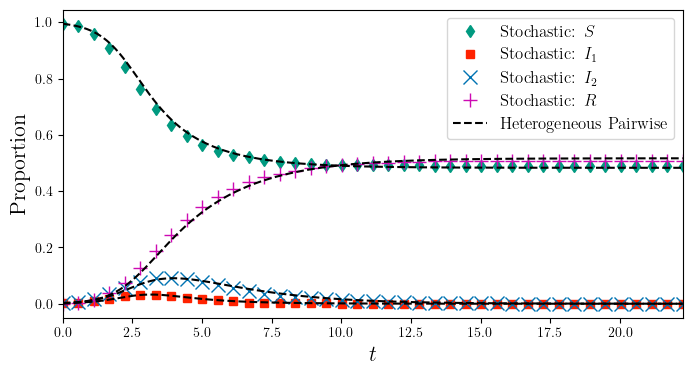

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import EoN
import numpy as np
from collections import defaultdict
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'

rng = np.random.default_rng(123)

gamma1 = 2
gamma2 = 0.5
tau1 = 0.8
tau2 = 0.2
p = 0.5

N=10000
initial_I_count = 50


deg_dist = [2]*int(N/2) + [5]*int(3*N/8) +  [15]*int(N/8)
rng.shuffle(deg_dist)
G = nx.configuration_model(deg_dist)
G.remove_edges_from(nx.selfloop_edges(G))

H_si1i2r = nx.DiGraph()
H_si1i2r.add_weighted_edges_from([ ('I1', 'R', gamma1), ('I2', 'R', gamma2)], weight='rate')

J_si1i2r = nx.DiGraph()
J_si1i2r.add_weighted_edges_from([(('I1', 'S'), ('I1', 'I1'), p*tau1), (('I1', 'S'), ('I1', 'I2'), (1-p)*tau1), (('I2', 'S'), ('I2', 'I1'), p*tau2), (('I2', 'S'), ('I2', 'I2'), (1-p)*tau2)], weight= 'rate' )

fig=plt.figure(figsize=(8,4))

IC = defaultdict(lambda: 'S')
for node in range(initial_I_count):
    if rng.random()<p:
        IC[node] = 'I1'
    else:
        IC[node] = 'I2'

return_statuses = ['S', 'I1', 'I2', 'R']

t_stoch, S_stoch, I1_stoch, I2_stoch, R_stoch = EoN.Gillespie_simple_contagion(G, H_si1i2r, J_si1i2r, IC, return_statuses=return_statuses, tmax = 200)  
S_stoch, I1_stoch, R_stoch = EoN.subsample(np.linspace(0,t_stoch[-1],41), t_stoch, S_stoch, I1_stoch, R_stoch)
I2_stoch = EoN.subsample(np.linspace(0,t_stoch[-1],41), t_stoch, I2_stoch)
t_stoch=np.linspace(0,t_stoch[-1],41)

plt.plot(t_stoch, S_stoch/N, 'd', color = colorS, label = 'Stochastic: $S$')
plt.plot(t_stoch, I1_stoch/N, 's', color = colorI, label = 'Stochastic: $I_1$')
plt.plot(t_stoch, I2_stoch/N, 'x', color = colorI2, markersize = 10, label = 'Stochastic: $I_2$')
plt.plot(t_stoch, R_stoch/N, '+', color=colorR, markersize = 10, label = 'Stochastic: $R$')

t_HPW, S_HPW, I1_HPW, I2_HPW, R_HPW = EoN.Simple_contagion_heterogeneous_pairwise_from_graph(G, H_si1i2r, J_si1i2r, IC, return_statuses,return_statuses=return_statuses, tmax = t_stoch[-1])


plt.plot(t_HPW, S_HPW/N, '--', color='k', label = 'Heterogeneous Pairwise')
plt.plot(t_HPW, I1_HPW/N, '--',color='k',)
plt.plot(t_HPW, I2_HPW/N, '--', color='k')
plt.plot(t_HPW, R_HPW/N, '--',color='k',)
plt.legend(fontsize=12)
plt.xlim([0,t_stoch[-1]])
plt.xlabel('$t$', fontsize=16)
plt.ylabel('Proportion', fontsize=16)

fig.savefig('SI1I2R_vs_HMF.png', dpi=900)

## Cooperative diseases


In [ ]:
#import nt

import EoN
import networkx as nx
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


#handling random seeds as described in
#https://networkx.org/documentation/stable/reference/randomness.html
import random
random.seed(1)        # or any integer
#np.random.seed(3)  11may2026a
#np.random.seed(123) 11may2026b

np.random.seed(11)
rng = np.random.default_rng()

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'

N = 2000000

initial_size1 = 8000
initial_size2 = 4000

epithreshold = 0.3*N #used as a threshold for deciding whether to rerun the simultion.

tau1=0.2
tau2=1
gamma1=1
gamma2=0.5



IC = defaultdict(lambda: 'SS')
for node in range(initial_size1):
    IC[node] = 'IS'
for node in range(initial_size1, initial_size1+initial_size2):
    IC[node] = 'SI'


#In the below:
#'SS' means a node susceptible to both diseases
#'SI' means susceptible to disease 1 and infected with disease 2
#'RS' means recovered from disease 1 and susceptible to disease 2.
#etc.

H = nx.DiGraph()  #DiGraph showing possible transitions that don't require an interaction
H.add_node('SS')
H.add_edge('SI', 'SR', rate = gamma1)
H.add_edge('IS', 'RS', rate = gamma1)
H.add_edge('II', 'IR', rate = gamma1)
H.add_edge('II', 'RI', rate = gamma1)
H.add_edge('IR', 'RR', rate = gamma2)
H.add_edge('RI', 'RR', rate = gamma2)

#In the below the edge (('SI', 'SS'), ('SI', 'SI')) means an
#'SI' node connected to an 'SS' node can lead to a transition in which
#the 'SS' node becomes 'SI'.  The rate of this transition is tau1.
#

J = nx.DiGraph()    #DiGraph showing transitiona that do require an interaction.
J.add_edge(('SI', 'SS'), ('SI', 'SI'), rate = tau1)
J.add_edge(('SI', 'IS'), ('SI', 'II'), rate = tau1)
J.add_edge(('SI', 'RS'), ('SI', 'RI'), rate = tau1)
J.add_edge(('II', 'SS'), ('II', 'SI'), rate = tau1)
J.add_edge(('II', 'IS'), ('II', 'II'), rate = tau1)
J.add_edge(('II', 'RS'), ('II', 'RI'), rate = tau1)

J.add_edge(('RI', 'SS'), ('RI', 'SI'), rate = tau2)
J.add_edge(('RI', 'IS'), ('RI', 'II'), rate = tau2)
J.add_edge(('RI', 'RS'), ('RI', 'RI'), rate = tau2)

J.add_edge(('IS', 'SS'), ('IS', 'IS'), rate = tau1)
J.add_edge(('IS', 'SI'), ('IS', 'II'), rate = tau1)
J.add_edge(('IS', 'SR'), ('IS', 'IR'), rate = tau1)
J.add_edge(('II', 'SS'), ('II', 'IS'), rate = tau1)
J.add_edge(('II', 'SI'), ('II', 'II'), rate = tau1)
J.add_edge(('II', 'SR'), ('II', 'IR'), rate = tau1)

J.add_edge(('IR', 'SS'), ('IR', 'IS'), rate = tau2)
J.add_edge(('IR', 'SI'), ('IR', 'II'), rate = tau2)
J.add_edge(('IR', 'SR'), ('IR', 'IR'), rate = tau2)

return_statuses = ('SS', 'SI', 'SR', 'IS', 'II', 'IR', 'RS', 'RI', 'RR')


for cc in range(100):
    for counter in range(20):
        print("counter = {}".format(counter))   
        G = nx.fast_gnp_random_graph(N, 5./(N-1))

        print("got G")

        t = [0,70]
        print("starting Gillespie")
        t, SS, SI, SR, IS, II, IR, RS, RI, RR = EoN.fast_simple_contagion(G, H, J, IC, return_statuses,
                                            tmax=float('Inf'), rng=rng)
        print(RS[-1]+SR[-1]+RR[-1])
        if RS[-1]+SR[-1]+RR[-1] > epithreshold:
            break
        else:
            print("Epidemic size below threshold, rerunning simulation")

    print("done with Gillespie, starting HPW")
    tt, SSSS, SSII, SSRR, IISS, IIII, IIRR, RRSS, RRII, RRRR = EoN.Simple_contagion_heterogeneous_pairwise_from_graph(G, H, J, IC, return_statuses,return_statuses=return_statuses, tmax = max(t[-1]+1,60))

    print("plotting")
    plt.figure()
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,3))
    fig.subplots_adjust(left=0.08, right=0.99, wspace=0.18, bottom=0.15, top=0.97 )# Increase right, decrease wspace for wider axes
    
    ax1.plot(t, (IS + II + IR)/N, color=colorI)
    ax1.plot(t, (SI + II + RI)/N, color=colorI2)

    ax1.plot(tt, (IISS + IIII + IIRR)/N, '--', color=colorI)
    ax1.plot(tt, (SSII + IIII + RRII)/N, '--', color=colorI2)

    #ax1.legend()   
    ax1.set_ylabel('Prevalence', fontsize=16)
    ax1.set_xlabel('$t$', fontsize=16)


    ax2.semilogy(t, (IS + II + IR)/N, label = 'Stochastic: $I_1$', color=colorI)
    ax2.semilogy(t, (SI + II + RI)/N, label = 'Stochastic: $I_2$', color=colorI2)

    ax2.semilogy(tt, (IISS + IIII + IIRR)/N, '--', color=colorI, label = 'Heterogeneous Pairwise: $I_1$')
    ax2.semilogy(tt, (SSII + IIII + RRII)/N, '--', color=colorI2, label = 'Heterogeneous Pairwise: $I_2$')

    ax2.legend(fontsize=12)
    ax2.set_xlabel('$t$', fontsize=16)
    ax2.set_ylim(bottom=0.0000001)
    fig.savefig('Coop_vs_HPW_X{}.png'.format(cc),  dpi=900)
    print('fig saved')
    #plt.clf()


counter = 0
got G
starting Gillespie
1821255
done with Gillespie, starting HPW


C:\Users\JCMiller\Dropbox\work\SpringerGithub\EoN\analytic.py:3404: RuntimeWarning: divide by zero encountered in divide
  Kfactor = np.where(Kvec==0, 0, (Kvec - 1) / Kvec ) # (k-1)/k for each k in K, except k=0 where it is 0.
C:\Users\JCMiller\Dropbox\work\SpringerGithub\EoN\analytic.py:3408: RuntimeWarning: invalid value encountered in divide
  term_ix = np.where(Qik[:,None] == 0, 0, bijz * Kfactor[:,None] * (QzQik[:,None] * QikQxl) / Qik[:,None]) #0 where den=0, otherwise using ratio
C:\Users\JCMiller\Dropbox\work\SpringerGithub\EoN\analytic.py:3412: RuntimeWarning: invalid value encountered in divide
  term_xi = np.where(Qik == 0, 0, bijz * Kfactor*(QxlQik*QikQz)/ Qik) #0 where den=0, otherwise using ratio


return_full_data should return edge counts as well
plotting


C:\Users\JCMiller\AppData\Local\Temp\ipykernel_33076\3199558915.py:144: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig('Coop_vs_HPW_X{}.png'.format(cc),  dpi=900)


fig saved
counter = 0
got G
starting Gillespie
1820758
done with Gillespie, starting HPW
return_full_data should return edge counts as well
plotting
fig saved
counter = 0
got G
starting Gillespie
1821214
done with Gillespie, starting HPW
return_full_data should return edge counts as well
plotting
fig saved
counter = 0
got G
starting Gillespie


KeyboardInterrupt: 

In [2]:
np.savez_compressed(
    "Coop_sim9May2026.npz",
    t=t,
    S=SS,
    SI=SI,
    SR=SR,
    IS=IS,
    II=II,
    IR=IR,
    RS=RS,
    RI=RI,
    RR=RR
)

199954749.26476464
999302010.02086
998604507.231731
return_full_data should return edge counts as well


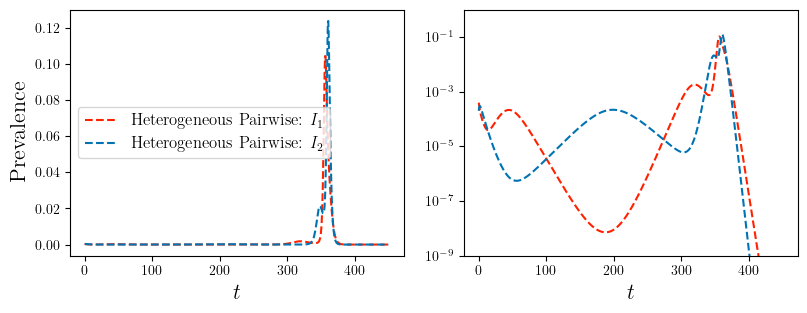

: 

In [ ]:
import EoN
import networkx as nx
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import math #for factorial - should figure out np.

from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

#handling random seeds as described in
#https://networkx.org/documentation/stable/reference/randomness.html
import random
random.seed(5)        # or any integer
np.random.seed(10)

rng = np.random.default_rng(seed = 1)

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'


'''
IC_Qik: list of numpy arrays
            IC_Qik[i] is a numpy array with IC_Qik[i][k] giving the number of nodes in status Q_i
            with degree k.  
        IC_QikQjl: list of lists of numpy 2D arrays
            IC_QikQjl[i][j] is a numpy array giving the number of pairs of nodes
            in status Q_i and Q_j with each degree pair.  
            if QiQj=IC_QikQjl[i][j], then QiQj[k][l] is the number of edges between degree k status Q_i
            nodes and degree l status Q_j nodes.
'''



#In the below:
#'SS' means a node susceptible to both diseases
#'SI' means susceptible to disease 1 and infected with disease 2
#'RS' means recovered from disease 1 and susceptible to disease 2.
#etc.

H = nx.DiGraph()  #DiGraph showing possible transitions that don't require an interaction
H.add_node('SS')
H.add_edge('SI', 'SR', rate = 1)
H.add_edge('IS', 'RS', rate = 1)
H.add_edge('II', 'IR', rate = 1)
H.add_edge('II', 'RI', rate = 1)
H.add_edge('IR', 'RR', rate = 0.5)
H.add_edge('RI', 'RR', rate = 0.5)

#In the below the edge (('SI', 'SS'), ('SI', 'SI')) means an
#'SI' node connected to an 'SS' node can lead to a transition in which
#the 'SS' node becomes 'SI'.  The rate of this transition is 0.2.
#

J = nx.DiGraph()    #DiGraph showing transitiona that do require an interaction.
J.add_edge(('SI', 'SS'), ('SI', 'SI'), rate = 0.2)
J.add_edge(('SI', 'IS'), ('SI', 'II'), rate = 0.2)
J.add_edge(('SI', 'RS'), ('SI', 'RI'), rate = 0.2)
J.add_edge(('II', 'SS'), ('II', 'SI'), rate = 0.2)
J.add_edge(('II', 'IS'), ('II', 'II'), rate = 0.2)
J.add_edge(('II', 'RS'), ('II', 'RI'), rate = 0.2)
J.add_edge(('RI', 'SS'), ('RI', 'SI'), rate = 1)
J.add_edge(('RI', 'IS'), ('RI', 'II'), rate = 1)
J.add_edge(('RI', 'RS'), ('RI', 'RI'), rate = 1)
J.add_edge(('IS', 'SS'), ('IS', 'IS'), rate = 0.2)
J.add_edge(('IS', 'SI'), ('IS', 'II'), rate = 0.2)
J.add_edge(('IS', 'SR'), ('IS', 'IR'), rate = 0.2)
J.add_edge(('II', 'SS'), ('II', 'IS'), rate = 0.2)
J.add_edge(('II', 'SI'), ('II', 'II'), rate = 0.2)
J.add_edge(('II', 'SR'), ('II', 'IR'), rate = 0.2)
J.add_edge(('IR', 'SS'), ('IR', 'IS'), rate = 1)
J.add_edge(('IR', 'SI'), ('IR', 'II'), rate = 1)
J.add_edge(('IR', 'SR'), ('IR', 'IR'), rate = 1)


#rho1 = 1500/2000000  
#rho2 = 1000/2000000

#rho1 = 750/2000000
#rho2 = 250/2000000

#rho1 = 600/2000000
#rho2 = 400/2000000   ---- need to solve to t=8000. 

rho1 = 800/2000000
rho2 = 400/2000000


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,3))
fig.subplots_adjust(left=0.08, right=0.99, wspace=0.18, bottom=0.15, top=0.97 )# Increase right, decrease wspace for wider axes

kmax = 15
lamb = 5
N = 200000000
IC_Qik=[]
status_list = ['SS', 'SI', 'SR', 'IS', 'II', 'IR', 'RS', 'RI', 'RR']
Nk = N*np.exp(-lamb)*np.array([lamb**k/math.factorial(k)  for k in range(kmax)])
IC_Qik = [0*Nk for status in status_list]
IC_Qik[0] = (1-rho1-rho2)*Nk
IC_Qik[1] = rho2*Nk
IC_Qik[3] = rho1*Nk

N_nk = np.array([k*Nk[k] for k in range(kmax)])

Nkl = np.outer(N_nk,N_nk)/(N*lamb)
print(np.sum(Nk))
print(np.sum([k*Nk[k] for k in range(kmax)]))
print(np.sum(Nkl))
IC_QikQjl = [[0*Nkl for status in status_list] for status in status_list]
IC_QikQjl[0][0] = (1-rho1-rho2)*(1-rho1-rho2)* Nkl # 1 - 2 rho1 - 2 rho2 + rho1^2 + 2*rho1*rho2 + rho2^2
IC_QikQjl[0][1] = (1-rho1-rho2)*rho1*Nkl           #       rho1          - rho1^2   - rho1*rho2
IC_QikQjl[1][0] = rho1*(1-rho1-rho2)*Nkl           #       rho1          - rho1^2   - rho1*rho2 
IC_QikQjl[1][1] = rho1*rho1*Nkl                    #                       rho1^2
IC_QikQjl[1][3] = rho1*rho2*Nkl                    #                                + rho1*rho2
IC_QikQjl[3][1] = rho1*rho2*Nkl                    #                                + rho1*rho2
IC_QikQjl[0][3] = rho2*(1-rho1-rho2)*Nkl           #                rho2            - rho1*rho2 - rho2^2
IC_QikQjl[3][0] = (1-rho1-rho2)*rho2*Nkl           #                rho2            - rho1*rho2 - rho2^2
IC_QikQjl[3][3] = rho2*rho2*Nkl                    #                                              rho2^2    


return_statuses = ('SS', 'SI', 'SR', 'IS', 'II', 'IR', 'RS', 'RI', 'RR')



t_ode, SS_ode, SI_ode, SR_ode, IS_ode, II_ode, IR_ode, RS_ode, RI_ode, RR_ode =  EoN.Simple_contagion_heterogeneous_pairwise(return_statuses, IC_Qik, IC_QikQjl, H, J, return_statuses=return_statuses, tmax = 450)

ax1.plot(t_ode, (IS_ode + II_ode + IR_ode)/N, '--', color = colorI, label='Heterogeneous Pairwise: $I_1$')
ax1.plot(t_ode, (SI_ode + II_ode + RI_ode)/N, '--', color = colorI2, label='Heterogeneous Pairwise: $I_2$')

ax2.semilogy(t_ode, (IS_ode + II_ode + IR_ode)/N, '--', color = colorI, label='Heterogeneous Pairwise: $I_1$')
ax2.semilogy(t_ode, (SI_ode + II_ode + RI_ode)/N, '--', color = colorI2, label='Heterogeneous Pairwise: $I_2$')


ax2.set_ylim([10**(-9), 1])
ax1.legend(loc = 'center left', fontsize=12)
ax1.set_xlabel('$t$', fontsize=16)
ax2.set_xlabel('$t$', fontsize=16)
ax1.set_ylabel('Prevalence', fontsize=16)

plt.savefig('Coop_HPW_deterministic.png', dpi=900)

